# Summary_Day7.ipynb  
## 선형회귀 · OLS · nn.Linear · 단순회귀/중회귀 · R² Score · 정규화

이번 7강은 머신러닝에서 가장 기본이 되는 **선형회귀 Linear Regression**를 정리하는 강의다.

앞 강의들에서 `nn.Linear`, `MSELoss`, `optimizer.step()`을 이미 써봤지만, 이번 강의에서는 그 흐름을 회귀 문제 관점에서 다시 정리한다.

강의 흐름을 한 줄로 정리하면 다음이다.

```text
입력 x로 연속적인 수치 y를 예측하는 가장 기본 모델 = 선형회귀
```

이번 강의에서 꼭 잡아야 하는 흐름은 다음이다.

```text
회귀 문제 정의
→ nn.Linear 구조 이해
→ 단순 선형 함수 테스트
→ 커스텀 nn.Module 모델 정의
→ MSELoss로 오차 계산
→ Boston 주택 가격 데이터 흐름 이해
→ RM 하나로 가격 예측
→ 경사하강법 학습
→ 학습률에 따른 수렴/발산 확인
→ RM + LSTAT 중회귀 확장
→ R² Score로 설명력 평가
→ Ridge, Lasso, ElasticNet 정규화 이해
```

> 필기 포인트:  
> 선형회귀는 딥러닝 입장에서 보면 **활성화 함수가 없는 뉴런 1개짜리 모델**이다.  
> 그래서 단순해 보이지만, 딥러닝 모델의 기본 연산 구조를 이해하는 데 매우 중요하다.

## 1. 라이브러리 준비

이번 실습에서는 NumPy, Matplotlib, PyTorch, scikit-learn을 사용한다.

### 함수/모듈 사용법

```python
import torch
import torch.nn as nn
import torch.optim as optim
```

- `torch`: Tensor와 자동 미분을 사용할 때 사용한다.
- `nn`: `nn.Linear`, `nn.MSELoss` 같은 신경망 구성 요소를 사용할 때 필요하다.
- `optim`: SGD, AdamW 같은 Optimizer를 사용할 때 사용한다.
- `LinearRegression`: scikit-learn의 OLS 선형회귀 모델이다.
- `StandardScaler`: 입력 feature를 표준화할 때 사용한다.

> 실습 메모:  
> 원본 강의는 Boston 주택 가격 데이터셋을 다룬다.  
> 이 Summary에서는 인터넷 없이 실행되도록 Boston 데이터의 구조를 흉내 낸 synthetic housing 데이터를 사용한다.  
> 핵심 개념은 원본과 동일하게 RM, LSTAT로 가격을 예측하는 흐름이다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

np.set_printoptions(suppress=True, precision=4)

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)
print("PyTorch:", torch.__version__)

device: cpu
PyTorch: 2.11.0+cpu


## 2. 회귀 문제와 분류 문제 차이

회귀는 연속적인 숫자를 예측하는 문제다.

```text
집값 예측
온도 예측
판매량 예측
```

분류는 정해진 class 중 하나를 고르는 문제다.

```text
스팸/정상 메일
고양이/강아지
질병/정상
```

핵심 차이는 다음이다.

```text
회귀: 얼마나 많이? How much?
분류: 무엇인가? Which one?
```

> 기억할 점:  
> 출력값이 실수이면 회귀, 출력값이 class label이면 분류라고 먼저 판단하면 된다.

In [2]:
problem_examples = {
    "회귀": ["집값 예측", "기온 예측", "판매량 예측"],
    "분류": ["스팸 필터", "암 진단", "품종 분류"]
}

for problem_type, examples in problem_examples.items():
    print(problem_type, ":", examples)

회귀 : ['집값 예측', '기온 예측', '판매량 예측']
분류 : ['스팸 필터', '암 진단', '품종 분류']


## 3. 선형회귀의 기본 수식

선형회귀의 가장 기본 수식은 다음이다.

```text
y = Wx + b
```

- `x`: 입력 데이터다.
- `W`: weight, 가중치다.
- `b`: bias, 편향이다.
- `y`: 예측값이다.

입력이 하나이면 1차 함수처럼 볼 수 있다.

```text
y = ax + b
```

입력이 여러 개이면 다음처럼 확장된다.

```text
y = w1*x1 + w2*x2 + ... + b
```

> 강의 포인트:  
> `nn.Linear`는 입력과 가중치의 선형 결합에 bias를 더하는 딥러닝의 기본 블록이다.

In [3]:
def linear_formula(x, w, b):
    return w * x + b

x_sample = np.array([-2, -1, 0, 1, 2])
y_sample = linear_formula(x_sample, w=2, b=1)

print("x:", x_sample)
print("y = 2x + 1:", y_sample)

x: [-2 -1  0  1  2]
y = 2x + 1: [-3 -1  1  3  5]


## 4. OLS 최소제곱법 개념

OLS는 Ordinary Least Squares, 보통 최소제곱법이라고 부른다.

목표는 다음이다.

```text
오차의 제곱합 Sum of Squared Errors를 가장 작게 만드는 직선을 찾는다.
```

오차는 실제값과 예측값의 차이다.

```text
residual = y_true - y_pred
```

OLS는 이 residual을 제곱해서 모두 더한 값을 최소화한다.

> 필기 포인트:  
> 제곱을 하기 때문에 큰 오차에 더 큰 패널티를 준다.  
> 그래서 OLS/MSE는 이상치에 민감할 수 있다.

In [4]:
y_true = np.array([3.0, 5.0, 7.0])
y_pred = np.array([2.5, 5.5, 8.0])

residual = y_true - y_pred
sse = np.sum(residual ** 2)

print("residual:", residual)
print("squared residual:", residual ** 2)
print("SSE:", sse)

residual: [ 0.5 -0.5 -1. ]
squared residual: [0.25 0.25 1.  ]
SSE: 1.5


### 함수 사용법: `np.sum()`

```python
np.sum(array)
```

- 배열 안의 값을 모두 더한다.
- OLS에서는 residual 제곱값을 모두 더할 때 사용한다.

## 5. nn.Linear 기본 생성

PyTorch에서 선형 함수는 `nn.Linear`로 만든다.

### 함수 사용법

```python
nn.Linear(in_features, out_features)
```

- `in_features`: 입력 feature 개수다.
- `out_features`: 출력 feature 개수다.
- 내부에는 `weight`와 `bias`가 자동으로 만들어진다.
- `weight`와 `bias`는 학습 대상이므로 기본적으로 `requires_grad=True`다.

In [5]:
l = nn.Linear(2, 3)

print(l)

for name, param in l.named_parameters():
    print("name:", name)
    print("shape:", param.shape)
    print("requires_grad:", param.requires_grad)

Linear(in_features=2, out_features=3, bias=True)
name: weight
shape: torch.Size([3, 2])
requires_grad: True
name: bias
shape: torch.Size([3])
requires_grad: True


출력 해석:

```text
nn.Linear(2, 3)
```

- 입력 feature 2개를 받는다.
- 출력 feature 3개를 만든다.
- weight shape은 `[3, 2]`가 된다.
- bias shape은 `[3]`이 된다.

> 헷갈림 포인트:  
> PyTorch의 Linear는 내부적으로 `y = xW^T + b` 형태로 계산한다.  
> 그래서 weight shape이 `(out_features, in_features)`로 보인다.

## 6. 1입력 1출력 선형 함수 만들기

가장 기본적인 회귀 모델은 1입력 1출력이다.

```text
y = wx + b
```

강의에서는 weight를 2, bias를 1로 직접 설정해서 `y = 2x + 1`을 만든다.

In [6]:
torch.manual_seed(123)

l1 = nn.Linear(1, 1)

print("초기 l1:")
print(l1)

for name, param in l1.named_parameters():
    print(name, param.data)

초기 l1:
Linear(in_features=1, out_features=1, bias=True)
weight tensor([[-0.4078]])
bias tensor([0.0331])


### 함수 사용법: `nn.init.constant_()`

```python
nn.init.constant_(layer.weight, 2.0)
nn.init.constant_(layer.bias, 1.0)
```

- Tensor의 모든 값을 지정한 상수로 채운다.
- `_`가 붙은 함수는 원본 Tensor를 직접 수정한다.

In [7]:
nn.init.constant_(l1.weight, 2.0)
nn.init.constant_(l1.bias, 1.0)

print("weight:", l1.weight)
print("bias:", l1.bias)

weight: Parameter containing:
tensor([[2.]], requires_grad=True)
bias: Parameter containing:
tensor([1.], requires_grad=True)


## 7. 1입력 1출력 함수 테스트

입력값 `[-2, -1, 0, 1, 2]`를 넣으면 `y = 2x + 1` 결과가 나와야 한다.

### 함수 사용법: `view(-1, 1)`

```python
x.view(-1, 1)
```

- 1차원 Tensor를 `[N, 1]` 형태의 2차원 Tensor로 바꾼다.
- `nn.Linear`는 기본적으로 batch 형태 입력을 받기 때문에 `[N, feature]` 모양이 필요하다.

In [8]:
x_np = np.arange(-2.0, 2.1, 1.0)
x = torch.tensor(x_np).float()
x = x.view(-1, 1)

y = l1(x)

print("x:")
print(x)

print("\ny:")
print(y.data)
print("y shape:", y.shape)

x:
tensor([[-2.],
        [-1.],
        [ 0.],
        [ 1.],
        [ 2.]])

y:
tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.]])
y shape: torch.Size([5, 1])


출력 해석:

```text
x = [-2, -1, 0, 1, 2]
y = [-3, -1, 1, 3, 5]
```

정확히 `y = 2x + 1`이 계산된다.

> 필기 포인트:  
> `nn.Linear`는 그냥 수식 하나가 아니라, batch 데이터를 한 번에 처리하는 함수다.

## 8. 2입력 1출력 선형 함수

입력이 2개면 수식은 다음처럼 된다.

```text
y = w1*x1 + w2*x2 + b
```

강의 예시에서는 모든 weight를 1, bias를 2로 둔다.

```text
y = x1 + x2 + 2
```

In [9]:
l2 = nn.Linear(2, 1)

nn.init.constant_(l2.weight, 1.0)
nn.init.constant_(l2.bias, 2.0)

x2_np = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

x2 = torch.tensor(x2_np).float()
y2 = l2(x2)

print("x2:")
print(x2)

print("\ny2:")
print(y2.data)

x2:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

y2:
tensor([[2.],
        [3.],
        [3.],
        [4.]])


결과 해석:

```text
[0, 0] → 0 + 0 + 2 = 2
[0, 1] → 0 + 1 + 2 = 3
[1, 0] → 1 + 0 + 2 = 3
[1, 1] → 1 + 1 + 2 = 4
```

> 기억할 점:  
> 입력 feature가 늘어나면 weight 개수도 늘어난다.

## 9. 2입력 3출력 선형 함수

출력이 여러 개일 수도 있다.

입력은 2개이고 출력은 3개이면, 서로 다른 3개의 선형식을 동시에 계산한다고 보면 된다.

```text
y1 = 1*x1 + 1*x2 + 2
y2 = 2*x1 + 2*x2 + 2
y3 = 3*x1 + 3*x2 + 2
```

In [10]:
l3 = nn.Linear(2, 3)

nn.init.constant_(l3.weight[0, :], 1.0)
nn.init.constant_(l3.weight[1, :], 2.0)
nn.init.constant_(l3.weight[2, :], 3.0)
nn.init.constant_(l3.bias, 2.0)

y3 = l3(x2)

print("weight:")
print(l3.weight)

print("\ny3:")
print(y3.data)
print("y3 shape:", y3.shape)

weight:
Parameter containing:
tensor([[1., 1.],
        [2., 2.],
        [3., 3.]], requires_grad=True)

y3:
tensor([[2., 2., 2.],
        [3., 4., 5.],
        [3., 4., 5.],
        [4., 6., 8.]])
y3 shape: torch.Size([4, 3])


출력 shape 해석:

```text
x2 shape = [4, 2]
y3 shape = [4, 3]
```

- 데이터 4개다.
- 각 데이터마다 출력 3개가 나온다.

## 10. 커스텀 클래스로 모델 정의하기

PyTorch 모델은 보통 `nn.Module`을 상속해서 만든다.

구조는 다음이다.

```python
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)

    def forward(self, x):
        return self.l1(x)
```

- `__init__`: 사용할 Layer를 준비한다.
- `forward`: 데이터가 Layer를 통과하는 흐름을 정의한다.
- `super().__init__()`: 부모 클래스인 `nn.Module` 초기화를 실행한다.

In [11]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)

    def forward(self, x):
        x1 = self.l1(x)
        return x1

net_demo = Net(1, 1)

print(net_demo)

Net(
  (l1): Linear(in_features=1, out_features=1, bias=True)
)


> 헷갈림 포인트:  
> `net(inputs)`처럼 모델을 함수처럼 부르면 내부적으로 `forward(inputs)`가 실행된다.  
> 직접 `net.forward(inputs)`를 부르는 것보다 `net(inputs)`를 쓰는 것이 PyTorch 방식이다.

In [12]:
inputs_demo = torch.ones(100, 1)

outputs_demo = net_demo(inputs_demo)

print("outputs shape:", outputs_demo.shape)
print(outputs_demo[:5])

outputs shape: torch.Size([100, 1])
tensor([[-0.5637],
        [-0.5637],
        [-0.5637],
        [-0.5637],
        [-0.5637]], grad_fn=<SliceBackward0>)


## 11. MSELoss로 손실 계산하기

회귀 문제에서는 보통 MSELoss를 많이 사용한다.

### 함수 사용법

```python
criterion = nn.MSELoss()
loss = criterion(outputs, labels)
```

- `outputs`: 모델 예측값이다.
- `labels`: 실제 정답값이다.
- 두 Tensor의 shape이 같아야 한다.

In [13]:
criterion_demo = nn.MSELoss()

labels_demo = torch.zeros(100, 1)

loss_demo = criterion_demo(outputs_demo, labels_demo)

print("loss:", loss_demo.item())

loss: 0.317752867937088


## 12. backward로 gradient 계산하기

Loss를 계산한 뒤 `backward()`를 호출하면 파라미터의 gradient가 계산된다.

### 함수 사용법

```python
loss.backward()
```

- 계산 그래프를 거꾸로 따라간다.
- `requires_grad=True`인 parameter의 `.grad`에 값이 저장된다.

In [14]:
loss_demo.backward()

print("weight grad:")
print(net_demo.l1.weight.grad)

print("\nbias grad:")
print(net_demo.l1.bias.grad)

weight grad:
tensor([[-1.1274]])

bias grad:
tensor([-1.1274])


> 기억할 점:  
> 선형회귀도 결국 `예측 → 손실 → 역전파 → 업데이트` 흐름으로 학습한다.

## 13. Boston 주택 가격 데이터 흐름 이해

원본 강의에서는 Boston Housing 데이터를 사용한다.

핵심 구조는 다음이다.

```text
데이터 개수: 506개
특성 개수: 13개
사용 특성 1: RM, 방의 평균 개수
추가 특성 2: LSTAT, 저소득자 비율
정답: 주택 가격
```

이번 Summary에서는 같은 구조를 유지하기 위해 synthetic housing 데이터를 만든다.

- `RM`: 방 개수처럼 동작하는 feature다.
- `LSTAT`: 저소득자 비율처럼 동작하는 feature다.
- `PRICE`: 주택 가격처럼 동작하는 target이다.

In [15]:
np.random.seed(42)

n_samples = 506

RM = np.random.normal(loc=6.3, scale=0.7, size=n_samples)
LSTAT = np.random.gamma(shape=2.2, scale=5.0, size=n_samples)
NOISE = np.random.normal(loc=0.0, scale=3.5, size=n_samples)

PRICE = 4.8 * RM - 0.72 * LSTAT + 4.0 + NOISE
PRICE = np.clip(PRICE, 5, 50)

x_org = np.column_stack([RM, LSTAT])
feature_names = np.array(["RM", "LSTAT"])
yt = PRICE

print("x_org shape:", x_org.shape)
print("yt shape:", yt.shape)
print("feature_names:", feature_names)
print("first 5 rows:")
print(x_org[:5])
print("first 5 targets:")
print(yt[:5])

x_org shape: (506, 2)
yt shape: (506,)
feature_names: ['RM' 'LSTAT']
first 5 rows:
[[6.6477 5.8432]
 [6.2032 4.5879]
 [6.7534 9.6687]
 [7.3661 4.7299]
 [6.1361 7.7943]]
first 5 targets:
[34.9493 35.5668 35.7522 38.5622 29.9183]


> 필기 포인트:  
> 실제 Boston 데이터에서는 13개 feature 중 RM 하나만 먼저 사용한다.  
> 그다음 LSTAT를 추가해서 중회귀로 확장한다.

## 14. RM 하나만 선택하기

단순회귀는 입력 변수가 하나인 회귀다.

```text
PRICE = W * RM + b
```

### 슬라이싱 사용법

```python
x = x_org[:, feature_names == "RM"]
```

- 모든 행을 가져온다.
- feature 이름이 RM인 열만 선택한다.
- 결과 shape은 `[N, 1]`이다.

In [16]:
x = x_org[:, feature_names == "RM"]

print("x shape:", x.shape)
print(x[:5])
print("yt first 5:", yt[:5])

x shape: (506, 1)
[[6.6477]
 [6.2032]
 [6.7534]
 [7.3661]
 [6.1361]]
yt first 5: [34.9493 35.5668 35.7522 38.5622 29.9183]


## 15. RM과 가격의 산점도

모델을 만들기 전에 산점도로 관계를 먼저 확인한다.

### 함수 사용법: `plt.scatter()`

```python
plt.scatter(x, yt, s=10)
```

- `x`: 방 개수 feature다.
- `yt`: 가격 target이다.
- `s`: 점 크기다.

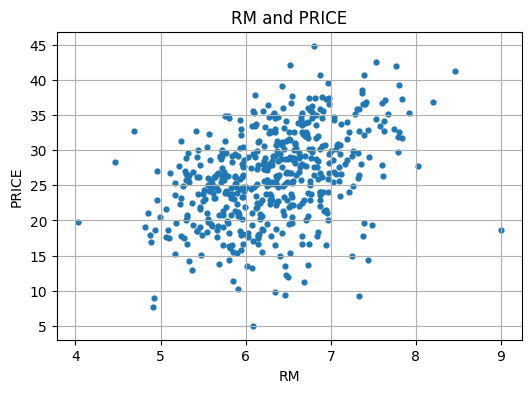

In [17]:
plt.scatter(x, yt, s=12)
plt.xlabel("RM")
plt.ylabel("PRICE")
plt.title("RM and PRICE")
plt.show()

그래프 해석:

- RM이 커질수록 PRICE가 대체로 증가한다.
- 완벽한 직선은 아니지만 양의 선형 관계가 보인다.
- 이 점들을 가장 잘 대표하는 직선을 찾는 것이 단순 선형회귀의 목표다.

## 16. 입력 차원과 출력 차원 정하기

`nn.Linear`를 만들려면 입력 feature 수와 출력 feature 수를 알아야 한다.

```python
n_input = x.shape[1]
n_output = 1
```

- `x.shape[1]`: feature 개수다.
- 회귀에서 가격 하나를 예측하므로 출력은 1이다.

In [18]:
n_input = x.shape[1]
n_output = 1

print("n_input:", n_input)
print("n_output:", n_output)

n_input: 1
n_output: 1


## 17. 초기값을 1로 둔 회귀 모델 만들기

강의에서는 weight와 bias를 모두 1로 초기화해서 학습 전 상태를 명확하게 확인했다.

In [19]:
class LinearRegressionNet(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)

        nn.init.constant_(self.l1.weight, 1.0)
        nn.init.constant_(self.l1.bias, 1.0)

    def forward(self, x):
        return self.l1(x)

net = LinearRegressionNet(n_input, n_output).to(device)

print(net)

for name, param in net.named_parameters():
    print(name, param.data)

LinearRegressionNet(
  (l1): Linear(in_features=1, out_features=1, bias=True)
)
l1.weight tensor([[1.]])
l1.bias tensor([1.])


> 기억할 점:  
> 초기값은 학습 전 출발점이다.  
> 같은 모델이라도 초기값, 학습률, Optimizer에 따라 학습 흐름이 달라질 수 있다.

## 18. Tensor로 변환하기

PyTorch 학습을 위해 NumPy 배열을 Tensor로 바꾼다.

### 함수 사용법

```python
torch.tensor(x).float().to(device)
```

- `torch.tensor(x)`: NumPy 배열을 Tensor로 바꾼다.
- `.float()`: float32 타입으로 변환한다.
- `.to(device)`: CPU 또는 GPU로 이동한다.

In [20]:
inputs = torch.tensor(x).float().to(device)
labels = torch.tensor(yt).float()

labels1 = labels.view(-1, 1).to(device)

print("inputs shape:", inputs.shape)
print("labels1 shape:", labels1.shape)

inputs shape: torch.Size([506, 1])
labels1 shape: torch.Size([506, 1])


### 함수 사용법: `labels.view(-1, 1)`

```python
labels.view(-1, 1)
```

- `[N]` 형태를 `[N, 1]` 형태로 바꾼다.
- 모델 출력이 `[N, 1]`이므로 정답도 같은 shape으로 맞춘다.

## 19. 손실 함수와 Optimizer 설정

회귀 문제이므로 MSELoss를 사용한다.

Optimizer는 SGD를 사용한다.

### 함수 사용법

```python
criterion = nn.MSELoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)
```

- `criterion`: 예측값과 정답을 비교한다.
- `optimizer`: 파라미터를 업데이트한다.
- `lr`: learning rate, 학습률이다.

In [21]:
criterion = nn.MSELoss()

lr = 0.01
optimizer = optim.SGD(net.parameters(), lr=lr)

print("criterion:", criterion)
print("optimizer:", optimizer)

criterion: MSELoss()
optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## 20. 한 번의 예측과 손실 계산

학습 루프에 들어가기 전에 한 번만 예측과 손실 계산을 해본다.

In [22]:
outputs = net(inputs)
loss = criterion(outputs, labels1)

print("outputs shape:", outputs.shape)
print("loss:", loss.item())

outputs shape: torch.Size([506, 1])
loss: 396.8753662109375


해석:

- 현재 weight와 bias는 아직 학습된 값이 아니다.
- 그래서 loss가 클 수 있다.
- 이제 `backward()`와 `optimizer.step()`으로 파라미터를 수정한다.

## 21. 경사하강법 한 번 실행하기

학습 한 step은 다음 순서다.

```text
1. optimizer.zero_grad()
2. outputs = net(inputs)
3. loss = criterion(outputs, labels)
4. loss.backward()
5. optimizer.step()
```

> 주의:  
> 보통 `zero_grad()`는 루프의 맨 앞에 둔다.  
> 이전 step의 gradient가 누적되는 것을 막기 위해서다.

In [23]:
optimizer.zero_grad()

outputs = net(inputs)
loss = criterion(outputs, labels1)

loss.backward()

print("before step weight:", net.l1.weight.data)
print("before step bias:", net.l1.bias.data)
print("weight grad:", net.l1.weight.grad)
print("bias grad:", net.l1.bias.grad)

optimizer.step()

print("\nafter step weight:", net.l1.weight.data)
print("after step bias:", net.l1.bias.data)

before step weight: tensor([[1.]])
before step bias: tensor([1.])
weight grad: tensor([[-241.0203]])
bias grad: tensor([-37.7887])

after step weight: tensor([[3.4102]])
after step bias: tensor([1.3779])


> 필기 포인트:  
> `loss.backward()`는 방향을 계산하는 단계고,  
> `optimizer.step()`은 실제로 파라미터를 바꾸는 단계다.

## 22. 반복 학습 루프 만들기

이제 1000번 반복해서 회귀 직선을 학습한다.

기록할 값은 다음이다.

```text
epoch
loss
```

`history`에 저장해두면 학습 곡선을 그릴 수 있다.

In [24]:
torch.manual_seed(42)

net = LinearRegressionNet(n_input, n_output).to(device)

criterion = nn.MSELoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

num_epochs = 1000
history = []

for epoch in range(num_epochs + 1):
    optimizer.zero_grad()

    outputs = net(inputs)
    loss = criterion(outputs, labels1)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        history.append([epoch, loss.item()])

history = np.array(history)

print("초기 손실값:", history[0, 1])
print("최종 손실값:", history[-1, 1])

for name, param in net.named_parameters():
    print(name, param.data.cpu().numpy())

초기 손실값: 396.8753662109375
최종 손실값: 35.942344665527344
l1.weight [[3.9157]]
l1.bias [1.5063]


코드 흐름:

```text
zero_grad → 예측 → 손실 → backward → step → 기록
```

> 시험 포인트:  
> 이 순서는 PyTorch 학습 루프의 기본 형태다.

## 23. 학습 곡선 확인

Loss가 반복에 따라 줄어드는지 확인한다.

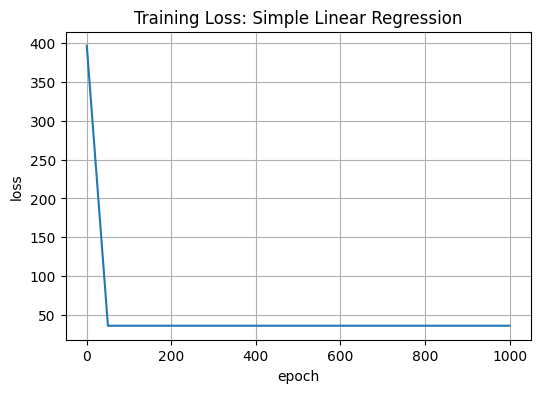

In [25]:
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss: Simple Linear Regression")
plt.show()

그래프 해석:

- Loss가 우하향하면 학습이 진행되고 있다는 뜻이다.
- 중간에 loss가 튀거나 `nan`이 나오면 학습률이 너무 크거나 데이터 스케일 문제가 있을 수 있다.

## 24. 학습된 회귀 직선 그리기

학습된 모델이 만든 직선을 산점도 위에 그린다.

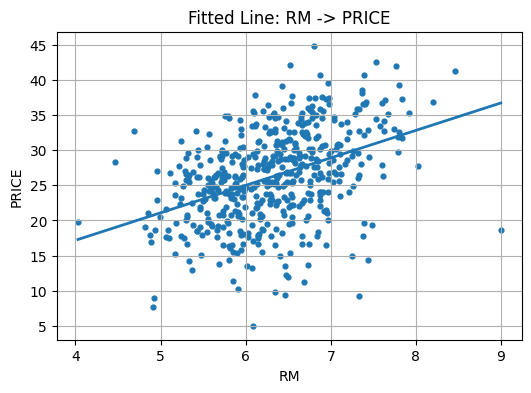

In [26]:
xse = np.array([x.min(), x.max()]).reshape(-1, 1)
Xse = torch.tensor(xse).float().to(device)

net.eval()
with torch.no_grad():
    Yse = net(Xse)

plt.scatter(x, yt, s=12)
plt.plot(xse, Yse.cpu().numpy(), linewidth=2)
plt.xlabel("RM")
plt.ylabel("PRICE")
plt.title("Fitted Line: RM -> PRICE")
plt.show()

그래프 해석:

- 점은 실제 데이터다.
- 선은 모델이 학습한 회귀 직선이다.
- 선이 데이터의 큰 흐름을 따라가면 모델이 관계를 어느 정도 학습한 것이다.

## 25. R² Score 직접 계산하기

R² Score는 모델이 데이터의 분산을 얼마나 설명하는지 나타내는 지표다.

공식은 다음이다.

```text
R² = 1 - SS_res / SS_tot
```

- `SS_res`: 잔차 제곱합이다.
- `SS_tot`: 전체 변동량이다.
- 1에 가까울수록 좋다.
- 0은 평균만 예측하는 baseline과 비슷하다는 뜻이다.
- 음수는 평균 예측보다 못하다는 경고다.

In [27]:
def r2_score_torch(y_true, y_pred):
    y_mean = y_true.mean()
    ss_tot = ((y_true - y_mean) ** 2).sum()
    ss_res = ((y_true - y_pred) ** 2).sum()
    return 1 - (ss_res / ss_tot)

with torch.no_grad():
    pred_train = net(inputs)
    r2_value = r2_score_torch(labels1, pred_train)

print("R2 score:", r2_value.item())

R2 score: 0.16564935445785522


> 기억할 점:  
> R²가 높다고 인과관계가 증명되는 것은 아니다.  
> 단순히 모델이 데이터 패턴을 어느 정도 설명한다는 뜻이다.

## 26. scikit-learn OLS와 PyTorch 결과 비교

scikit-learn의 `LinearRegression`은 OLS를 빠르게 계산해준다.

### 함수 사용법

```python
model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)
```

- `fit`: 데이터로 모델을 학습한다.
- `predict`: 학습된 모델로 예측한다.

In [28]:
ols = LinearRegression()
ols.fit(x, yt)

ols_pred = ols.predict(x)

print("OLS coefficient:", ols.coef_)
print("OLS intercept:", ols.intercept_)
print("OLS R2:", r2_score(yt, ols_pred))
print("OLS RMSE:", np.sqrt(mean_squared_error(yt, ols_pred)))

OLS coefficient: [3.8864]
OLS intercept: 1.6926757470291172
OLS R2: 0.16565889547617008
OLS RMSE: 5.995159824655643


PyTorch는 gradient descent로 반복 학습해서 파라미터를 찾는다.  
scikit-learn의 LinearRegression은 닫힌 형태의 OLS 해를 직접 구한다.

> 필기 포인트:  
> 간단한 선형회귀만 빠르게 풀 때는 scikit-learn이 편하고,  
> 딥러닝 모델로 확장할 때는 PyTorch 구조가 필요하다.

## 27. 중회귀 모델로 확장하기

중회귀는 입력 변수가 2개 이상인 회귀다.

이번에는 RM 하나만 쓰지 않고 LSTAT도 추가한다.

```text
PRICE = w1*RM + w2*LSTAT + b
```

강의에서도 RM과 LSTAT 두 특성을 사용해 성능이 좋아지는지 확인했다.

In [29]:
x_add = x_org[:, feature_names == "LSTAT"]
x_multi = np.hstack([x, x_add])

print("x_multi shape:", x_multi.shape)
print(x_multi[:5])

x_multi shape: (506, 2)
[[6.6477 5.8432]
 [6.2032 4.5879]
 [6.7534 9.6687]
 [7.3661 4.7299]
 [6.1361 7.7943]]


입력 feature가 2개가 되었으므로 `n_input`도 2가 된다.

```python
n_input = x_multi.shape[1]
```

In [30]:
n_input_multi = x_multi.shape[1]

print("n_input_multi:", n_input_multi)

n_input_multi: 2


## 28. 중회귀에서 학습률이 너무 클 때

원본 강의에서는 입력 변수를 2개로 늘린 뒤 학습률 0.01로 학습하면 손실이 `inf`, `nan`으로 발산하는 경우를 보여줬다.

여기서도 스케일이 큰 데이터를 그대로 쓰면 학습률이 너무 커서 불안정해질 수 있다.

> 필기 포인트:  
> feature가 늘어나면 손실 곡면도 달라지고, 같은 learning rate가 더 이상 안전하지 않을 수 있다.

In [31]:
inputs_multi = torch.tensor(x_multi).float().to(device)

net_bad_lr = LinearRegressionNet(n_input_multi, 1).to(device)

criterion = nn.MSELoss()
optimizer_bad = optim.SGD(net_bad_lr.parameters(), lr=0.1)

bad_history = []

for epoch in range(101):
    optimizer_bad.zero_grad()

    outputs = net_bad_lr(inputs_multi)
    loss = criterion(outputs, labels1)

    if not torch.isfinite(loss):
        print("loss가 발산함:", loss.item(), "epoch:", epoch)
        break

    loss.backward()
    optimizer_bad.step()

    if epoch % 10 == 0:
        bad_history.append([epoch, loss.item()])

bad_history = np.array(bad_history)

print("recorded history:")
print(bad_history[:5])

loss가 발산함: inf epoch: 12
recorded history:
[[0.0000e+00 2.1935e+02]
 [1.0000e+01 2.9775e+32]]


해석:

- 학습률이 너무 크면 정답 근처를 지나쳐버릴 수 있다.
- 손실이 계속 커지다가 `inf`나 `nan`이 될 수 있다.
- 이런 상황에서는 학습률을 줄이거나 입력을 표준화해야 한다.

## 29. 학습률을 줄여서 중회귀 학습하기

학습률을 낮추면 발산하던 모델이 안정적으로 학습될 수 있다.

In [32]:
torch.manual_seed(42)

net_multi_small_lr = LinearRegressionNet(n_input_multi, 1).to(device)

criterion = nn.MSELoss()
optimizer_multi_small_lr = optim.SGD(net_multi_small_lr.parameters(), lr=0.001)

history_multi_small_lr = []

for epoch in range(2001):
    optimizer_multi_small_lr.zero_grad()

    outputs = net_multi_small_lr(inputs_multi)
    loss = criterion(outputs, labels1)

    loss.backward()
    optimizer_multi_small_lr.step()

    if epoch % 100 == 0:
        history_multi_small_lr.append([epoch, loss.item()])

history_multi_small_lr = np.array(history_multi_small_lr)

print("초기 손실값:", history_multi_small_lr[0, 1])
print("최종 손실값:", history_multi_small_lr[-1, 1])

초기 손실값: 219.3516082763672
최종 손실값: 12.09171199798584


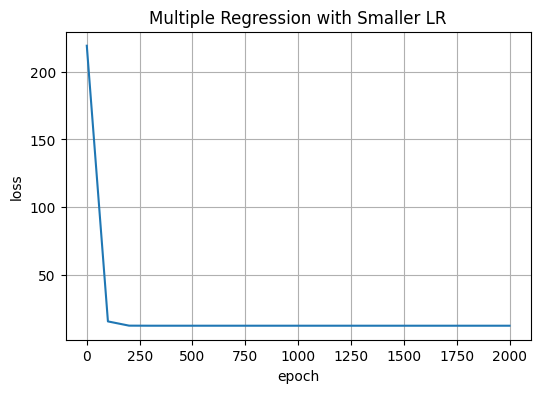

In [33]:
plt.plot(history_multi_small_lr[:, 0], history_multi_small_lr[:, 1])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Multiple Regression with Smaller LR")
plt.show()

그래프 해석:

- 학습률을 줄이면 손실이 안정적으로 내려간다.
- 단, 너무 작으면 학습 속도가 느려질 수 있다.

> 시험 포인트:  
> 학습률은 단순한 옵션이 아니라 학습 성공 여부를 결정하는 중요한 하이퍼파라미터다.

## 30. 표준화 후 중회귀 학습하기

학습률 문제의 또 다른 해결 방법은 입력 feature를 표준화하는 것이다.

### 함수 사용법: `StandardScaler`

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

- 평균을 0, 표준편차를 1에 가깝게 만든다.
- feature scale 차이를 줄여 학습을 안정화한다.

In [34]:
scaler_multi = StandardScaler()
x_multi_scaled = scaler_multi.fit_transform(x_multi)

inputs_multi_scaled = torch.tensor(x_multi_scaled).float().to(device)

torch.manual_seed(42)

net_multi_scaled = LinearRegressionNet(n_input_multi, 1).to(device)

criterion = nn.MSELoss()
optimizer_multi_scaled = optim.SGD(net_multi_scaled.parameters(), lr=0.05)

history_multi_scaled = []

for epoch in range(1001):
    optimizer_multi_scaled.zero_grad()

    outputs = net_multi_scaled(inputs_multi_scaled)
    loss = criterion(outputs, labels1)

    loss.backward()
    optimizer_multi_scaled.step()

    if epoch % 50 == 0:
        history_multi_scaled.append([epoch, loss.item()])

history_multi_scaled = np.array(history_multi_scaled)

print("초기 손실값:", history_multi_scaled[0, 1])
print("최종 손실값:", history_multi_scaled[-1, 1])

초기 손실값: 684.1205444335938
최종 손실값: 12.028169631958008


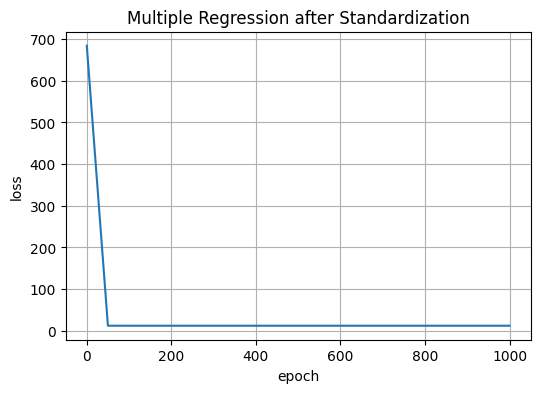

In [35]:
plt.plot(history_multi_scaled[:, 0], history_multi_scaled[:, 1])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Multiple Regression after Standardization")
plt.show()

그래프 해석:

- 입력을 표준화하면 더 큰 learning rate에서도 안정적으로 학습될 수 있다.
- 딥러닝에서 입력 스케일 조정이 중요한 이유를 보여준다.

## 31. 단순회귀와 중회귀 성능 비교

RM 하나만 쓴 모델과 RM+LSTAT를 쓴 모델을 R²로 비교한다.

In [36]:
with torch.no_grad():
    pred_simple = net(inputs).cpu().numpy().ravel()
    pred_multi = net_multi_scaled(inputs_multi_scaled).cpu().numpy().ravel()

simple_r2 = r2_score(yt, pred_simple)
multi_r2 = r2_score(yt, pred_multi)

simple_mae = mean_absolute_error(yt, pred_simple)
multi_mae = mean_absolute_error(yt, pred_multi)

print("Simple Regression R2:", simple_r2)
print("Multiple Regression R2:", multi_r2)

print("Simple Regression MAE:", simple_mae)
print("Multiple Regression MAE:", multi_mae)

Simple Regression R2: 0.16564942667283344
Multiple Regression R2: 0.7207831438064457
Simple Regression MAE: 4.708713781999379
Multiple Regression MAE: 2.7631375176350397


해석:

- R²가 높을수록 데이터의 변동성을 더 잘 설명한다.
- MAE가 낮을수록 평균 절대 오차가 작다.
- 추가 feature가 의미 있는 정보를 주면 중회귀 성능이 좋아질 수 있다.

## 32. R² 값의 의미

R²는 다음처럼 해석한다.

```text
R² ≈ 1: 모델이 데이터 변동을 거의 잘 설명한다.
R² ≈ 0: 평균만 예측하는 모델과 비슷하다.
R² < 0: 평균만 예측하는 것보다 못하다.
```

예를 들어 R²가 0.85라면 다음처럼 이해할 수 있다.

```text
전체 변동성 중 약 85%를 모델이 설명한다.
나머지 15%는 설명하지 못한 오차나 noise다.
```

> 주의:  
> R²가 높아도 인과관계를 의미하지는 않는다.

In [37]:
r2_examples = {
    "R2 = 1.0": "거의 완벽하게 설명한다",
    "R2 = 0.0": "평균 예측과 비슷하다",
    "R2 < 0": "평균보다 못한 모델일 수 있다"
}

for key, value in r2_examples.items():
    print(key, ":", value)

R2 = 1.0 : 거의 완벽하게 설명한다
R2 = 0.0 : 평균 예측과 비슷하다
R2 < 0 : 평균보다 못한 모델일 수 있다


## 33. 과적합 Overfitting 개념

과적합은 모델이 훈련 데이터에는 너무 잘 맞지만, 새로운 데이터에는 약한 상태다.

대표적인 징후는 다음이다.

```text
Train Loss는 계속 감소
Validation Loss는 어느 순간부터 증가
두 loss 사이의 gap이 커짐
```

해결 방법 예시는 다음이다.

- Ridge
- Lasso
- ElasticNet
- Early Stopping
- 데이터 추가

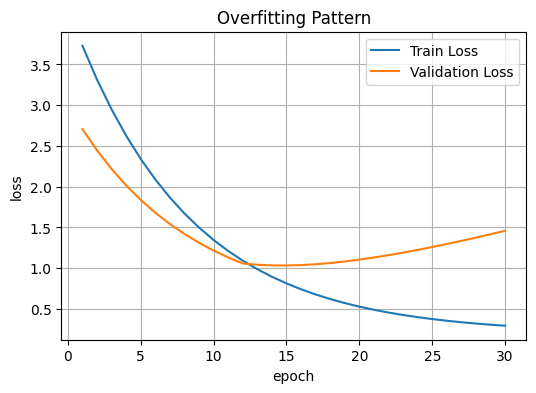

In [38]:
epochs = np.arange(1, 31)

train_loss_curve = 4.0 * np.exp(-epochs / 8) + 0.2
val_loss_curve = 2.5 * np.exp(-epochs / 8) + 0.5 + np.maximum(epochs - 12, 0) * 0.05

plt.plot(epochs, train_loss_curve, label="Train Loss")
plt.plot(epochs, val_loss_curve, label="Validation Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Overfitting Pattern")
plt.legend()
plt.show()

그래프 해석:

- train loss는 계속 내려간다.
- validation loss는 중간 이후 다시 올라간다.
- 이 구간부터 과적합을 의심할 수 있다.

## 34. Ridge Regression L2 정규화

Ridge는 L2 정규화를 사용하는 회귀 모델이다.

공식 느낌은 다음이다.

```text
Loss = MSE + λ||W||²
```

- weight의 제곱합을 패널티로 더한다.
- weight가 너무 커지는 것을 막는다.
- 모든 feature를 조금씩 사용하는 경향이 있다.

### PyTorch 사용법

```python
optim.SGD(model.parameters(), lr=0.1, weight_decay=lambda_l2)
```

`weight_decay`가 L2 정규화 역할을 한다.

In [39]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    x_multi,
    yt,
    test_size=0.25,
    random_state=42
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_r_scaled, y_train_r)

ridge_pred = ridge.predict(X_test_r_scaled)

print("Ridge coefficients:", ridge.coef_)
print("Ridge intercept:", ridge.intercept_)
print("Ridge R2:", r2_score(y_test_r, ridge_pred))

Ridge coefficients: [ 3.2013 -4.8359]
Ridge intercept: 25.972777935171365
Ridge R2: 0.7070259402831381


> 기억할 점:  
> Ridge는 계수를 0에 가깝게 줄이지만, 보통 완전히 0으로 만들지는 않는다.  
> 다중공선성이 있거나 안정적인 예측이 중요할 때 자주 사용한다.

## 35. Lasso Regression L1 정규화

Lasso는 L1 정규화를 사용하는 회귀 모델이다.

공식 느낌은 다음이다.

```text
Loss = MSE + λ∑|W|
```

- weight의 절댓값 합을 패널티로 더한다.
- 덜 중요한 feature의 weight를 완전히 0으로 만들 수 있다.
- 그래서 feature selection 효과가 있다.

PyTorch Optimizer에는 L1을 직접 넣는 옵션이 없어서 loss에 직접 더해야 한다.

In [40]:
lasso = Lasso(alpha=0.05, max_iter=10000)
lasso.fit(X_train_r_scaled, y_train_r)

lasso_pred = lasso.predict(X_test_r_scaled)

print("Lasso coefficients:", lasso.coef_)
print("Lasso intercept:", lasso.intercept_)
print("Lasso R2:", r2_score(y_test_r, lasso_pred))

Lasso coefficients: [ 3.1568 -4.7955]
Lasso intercept: 25.972777935171365
Lasso R2: 0.7071226871658433


> 필기 포인트:  
> Lasso는 해석력이 중요하거나 feature가 너무 많을 때 생각할 수 있다.  
> 다만 상관관계가 높은 feature 중 하나만 임의로 선택하는 불안정성이 있을 수 있다.

## 36. PyTorch에서 L1 패널티 직접 추가하기

PyTorch에서 L1 정규화를 직접 구현하려면 loss에 weight 절댓값 합을 더한다.

### 기본 패턴

```python
mse_loss = criterion(pred, y)
l1_norm = sum(p.abs().sum() for name, p in model.named_parameters() if "weight" in name)
loss = mse_loss + lambda_l1 * l1_norm
```

- bias는 제외하고 weight에만 주는 경우가 많다.

In [41]:
lambda_l1 = 0.001

model_l1_demo = LinearRegressionNet(2, 1)

sample_input = torch.randn(10, 2)
sample_target = torch.randn(10, 1)

criterion = nn.MSELoss()

pred_l1_demo = model_l1_demo(sample_input)
mse_l1_demo = criterion(pred_l1_demo, sample_target)

l1_norm = sum(
    p.abs().sum()
    for name, p in model_l1_demo.named_parameters()
    if "weight" in name
)

loss_with_l1 = mse_l1_demo + lambda_l1 * l1_norm

print("MSE only:", mse_l1_demo.item())
print("L1 norm:", l1_norm.item())
print("MSE + L1:", loss_with_l1.item())

MSE only: 2.8751368522644043
L1 norm: 2.0
MSE + L1: 2.8771369457244873


## 37. ElasticNet: L1 + L2 결합

ElasticNet은 Ridge와 Lasso를 합친 방식이다.

```text
Loss = MSE + α|W|₁ + λ|W|²
```

- Lasso의 feature selection 효과를 가진다.
- Ridge의 안정성도 함께 가진다.
- feature가 많고 서로 상관관계가 있을 때 유용할 수 있다.

In [42]:
elastic = ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000)
elastic.fit(X_train_r_scaled, y_train_r)

elastic_pred = elastic.predict(X_test_r_scaled)

print("ElasticNet coefficients:", elastic.coef_)
print("ElasticNet intercept:", elastic.intercept_)
print("ElasticNet R2:", r2_score(y_test_r, elastic_pred))

ElasticNet coefficients: [ 3.0973 -4.6987]
ElasticNet intercept: 25.972777935171365
ElasticNet R2: 0.7068509815636701


## 38. Ridge, Lasso, ElasticNet 비교

세 정규화 방식의 차이를 간단히 비교한다.

In [43]:
models = {
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic
}

for name, model in models.items():
    pred = model.predict(X_test_r_scaled)
    print(
        name,
        "| R2:", round(r2_score(y_test_r, pred), 4),
        "| MAE:", round(mean_absolute_error(y_test_r, pred), 4),
        "| coef:", np.round(model.coef_, 4)
    )

Ridge | R2: 0.707 | MAE: 2.8025 | coef: [ 3.2013 -4.8359]
Lasso | R2: 0.7071 | MAE: 2.8036 | coef: [ 3.1568 -4.7955]
ElasticNet | R2: 0.7069 | MAE: 2.8078 | coef: [ 3.0973 -4.6987]


정리:

- Ridge는 계수를 작게 줄여 안정성을 높인다.
- Lasso는 일부 계수를 0으로 만들어 feature selection 효과를 낸다.
- ElasticNet은 L1과 L2를 함께 사용한다.

## 39. MSE, R², 정규화의 역할 구분

강의 마지막 정리에서 중요한 구분이다.

| 요소 | 역할 | 사용 시점 |
|---|---|---|
| MSE | 학습 목표, loss function | 학습 루프 내부 |
| R² Score | 성능 평가 지표 | 학습 완료 후 |
| Ridge/Lasso | 일반화 개선, 정규화 | 모델 설계 또는 loss 정의 |

> 헷갈림 포인트:  
> MSE는 모델을 학습시키는 기준이고, R²는 학습 후 모델 성능을 해석하는 지표다.  
> Ridge/Lasso는 과적합을 줄이기 위해 손실에 패널티를 추가하는 방식이다.

In [44]:
role_summary = {
    "MSE": "학습 루프 안에서 Optimizer가 줄이려는 손실",
    "R2 Score": "학습 완료 후 모델의 설명력을 보는 평가 지표",
    "Ridge/Lasso": "과적합을 줄이기 위한 정규화 기법"
}

for key, value in role_summary.items():
    print(f"{key}: {value}")

MSE: 학습 루프 안에서 Optimizer가 줄이려는 손실
R2 Score: 학습 완료 후 모델의 설명력을 보는 평가 지표
Ridge/Lasso: 과적합을 줄이기 위한 정규화 기법


## 40. 주요 함수 / 변수 / 약어 정리

| 이름 | 뜻 | 어떻게 쓰는지 |
|---|---|---|
| `x` | 입력 데이터 | feature 값을 담는다 |
| `y`, `yt` | 정답 데이터 | 예측해야 하는 target이다 |
| `RM` | 방 평균 개수 | 주택 가격 예측 feature |
| `LSTAT` | 저소득자 비율 | 추가 feature |
| `W`, `weight` | 가중치 | feature 영향력 |
| `b`, `bias` | 편향 | 기본 출력값 |
| `nn.Linear` | 선형 Layer | `nn.Linear(in_features, out_features)` |
| `in_features` | 입력 feature 수 | 입력 열 개수 |
| `out_features` | 출력 feature 수 | 예측값 개수 |
| `nn.Module` | PyTorch 모델 부모 클래스 | 커스텀 모델 정의 시 상속 |
| `__init__` | 모델 뼈대 정의 | Layer 선언 |
| `forward` | 데이터 흐름 정의 | 순전파 로직 |
| `criterion` | 손실 함수 | `nn.MSELoss()` |
| `optimizer` | 최적화 함수 | `optim.SGD(...)` |
| `lr` | learning rate | 학습률 |
| `epoch` | 반복 횟수 | 전체 학습 반복 단위 |
| `loss` | 손실 | 예측과 정답의 차이 |
| `MSE` | 평균 제곱 오차 | 회귀 표준 손실 |
| `OLS` | 최소제곱법 | 오차 제곱합 최소화 |
| `R²` | 결정계수 | 설명력 평가 |
| `Ridge` | L2 정규화 | `weight_decay`와 연결 |
| `Lasso` | L1 정규화 | feature selection 효과 |
| `ElasticNet` | L1+L2 정규화 | Ridge와 Lasso 결합 |

## 41. 시험용 요약

```text
선형회귀 = 연속적인 숫자를 예측하는 가장 기본적인 회귀 모델
```

꼭 기억할 것:

- 회귀는 연속적인 실수값을 예측한다.
- 분류는 정해진 class label 중 하나를 고른다.
- 선형회귀 기본식은 `y = Wx + b`다.
- `nn.Linear`는 PyTorch의 선형 변환 Layer다.
- PyTorch Linear는 내부적으로 `y = xW^T + b`를 계산한다.
- `nn.Linear(in_features, out_features)`에서 입력과 출력 차원을 맞춰야 한다.
- weight shape은 `[out_features, in_features]`다.
- bias shape은 `[out_features]`다.
- 1입력 1출력은 `y = wx + b`와 같다.
- 2입력 1출력은 `y = w1x1 + w2x2 + b`다.
- 커스텀 모델은 `nn.Module`을 상속해서 만든다.
- `__init__`은 Layer를 정의하는 곳이다.
- `forward`는 데이터 흐름을 정의하는 곳이다.
- `net(inputs)`를 호출하면 내부적으로 `forward`가 실행된다.
- 회귀 손실함수로 `nn.MSELoss()`를 많이 쓴다.
- 학습 루프는 `zero_grad → forward → loss → backward → step` 순서다.
- OLS는 오차 제곱합을 최소화하는 방법이다.
- R²는 모델이 데이터 변동성을 얼마나 설명하는지 나타낸다.
- R²가 1에 가까울수록 좋고, 0은 평균 모델과 비슷하다.
- R²가 음수면 평균보다 못한 모델일 수 있다.
- 입력 변수가 하나면 단순회귀, 둘 이상이면 중회귀다.
- 학습률이 너무 크면 loss가 `inf`나 `nan`으로 발산할 수 있다.
- 입력 표준화는 학습을 안정화하는 데 도움을 준다.
- Ridge는 L2 정규화다.
- Lasso는 L1 정규화다.
- ElasticNet은 L1과 L2를 결합한다.
- MSE는 학습용 손실이고, R²는 평가 지표다.